## 2-D Ising Model, using Metropolis Monte Carlo

# Flowchart

1. Generate the spin lattice by declaring all the variables

2. Initialize the lattice with values of spin and calculate the initial magnetisation and energy
3. Evolve the lattice using Monte Carlo Steps at a particular temperature
4. Generate microstates at a particular temperature

5. Calculate the thermodynamic quantities
6. Change T and plot the quantities wrt change in T

Enter the length of the lattice along one dimension = 40
Enter the number of iterations to do for a specific temperature = 10000
Initial Magnetisation is 1600
Initial Energy of the lattice if -3200.0


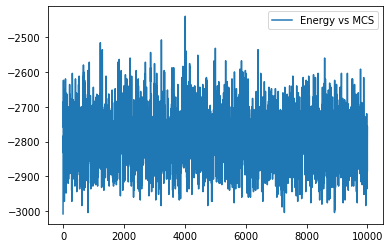

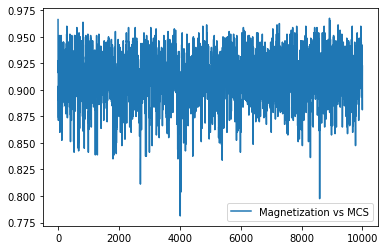

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import exp


J_ising=1    #Coupling Constant
T=2           
L=int(input("Enter the length of the lattice along one dimension = "))
n_iter=int(input("Enter the number of iterations to do for a specific temperature = "))
N=L*L # Total number of spins in the system

# STEP 1: declaring the lattice with random spin values of 1 and -1

spin=np.random.choice([1],size=(L,L)) 
E=0
M=0

#Periodic Boundary Conditions

# STEP 2 : Calculation of Energy and Magnetisation based on initial spin-lattice (declared randomly)

for i in range(L):
    for j in range(L):
        right = spin[0 if i==L-1 else i+1, j]
        left  = spin[L-1 if i==0 else i-1, j]
        up    = spin[i, 0 if j==L-1 else j+1]
        down  = spin[i, L-1 if j==0 else j-1]

        E+=-J_ising*(spin[i,j]*(right+left+up+down))
        M+=spin[i,j]
E=E/2
                     
print(f'Initial Magnetisation is {M}')
print(f'Initial Energy of the lattice if {E}')


# Step 3 : Equilibration, i.e. evolving the lattice over time, and minimising the energy, according to Metropolis Algorithm

E_list=[]
M_list=[]


for time in range(n_iter):
    for mm in range(N):
            i=np.random.randint(0,L)
            j=np.random.randint(0,L)
            
            right = spin[0 if i==L-1 else i+1, j]
            left  = spin[L-1 if i==0 else i-1, j]
            up    = spin[i, 0 if j==L-1 else j+1]
            down  = spin[i, L-1 if j==0 else j-1]
            
            
            E_i=-J_ising*(spin[i,j]*(right+left+up+down))
            
            #attempting a trial flip
            
            spin[i,j]= -spin[i,j]
            
            E_f= -J_ising*(spin[i,j]*(right+left+up+down))
            dE=E_f-E_i
            
            prob=exp(-dE/T)
            
            if dE<0:
                E+=dE
                M+=2*spin[i,j]
                
            else:
                q=np.random.uniform(0,1)
                if(q<prob):
                    E+=dE
                    M+=2*spin[i,j]
                else:
                    spin[i,j]= -spin[i,j]
                
                
    M_=M/N    
    
    E_list.append(E)
    M_list.append(M_)
 



 
data_E = pd.DataFrame(
    {"Monte Carlo Time Steps": range(n_iter), "Energy": E_list})


data_M = pd.DataFrame(
    {"Monte Carlo Time Steps": range(n_iter), "Magnetization": M_list}
)

plt.plot(data_E["Monte Carlo Time Steps"], data_E["Energy"], label="Energy vs MCS")


plt.legend()  
plt.show()
plt.plot(
    data_M["Monte Carlo Time Steps"],
    data_M["Magnetization"],
    label="Magnetization vs MCS",
)
plt.legend()
plt.show()


## Doing the same using KMC

1. Calculate the change in energy for all possible spin flips
2. Find the rate for each transition at each time step
3. Calculate cumulative probabilities (partial sums of rates) and compare them with a random number to check exactly for the spin which flips
4. While remaining in the time loop, append the values of M, E, and the waiting times.
5. Plots



Enter the length of the lattice along one dimension = 40
Enter the number of iterations to do for a specific temperature = 10000
Initial Magnetisation is 54
Initial Energy of the lattice if -92.0


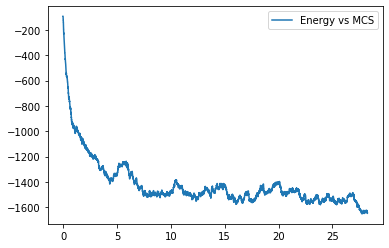

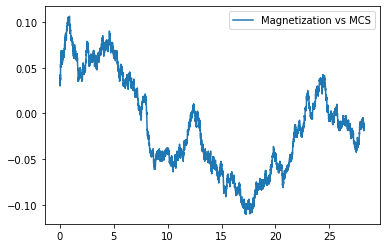

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import exp

J_ising=1    #Coupling Constant
T=2           
L=int(input("Enter the length of the lattice along one dimension = "))
n_iter=int(input("Enter the number of iterations to do for a specific temperature = "))
N=L*L # Total number of spins in the system


# STEP 1: declaring the lattice with random spin values of 1 and -1

spin=np.random.choice([1, -1],size=(L,L)) 
E=0
M=0

# Periodic Boundary Conditions

# STEP 2 : Calculation of Energy and Magnetisation based on initial spin-lattice (declared randomly)

for i in range(L):
    for j in range(L):
        right = spin[0 if i==L-1 else i+1, j]
        left  = spin[L-1 if i==0 else i-1, j]
        up    = spin[i, 0 if j==L-1 else j+1]
        down  = spin[i, L-1 if j==0 else j-1]

        E+=-J_ising*(spin[i,j]*(right+left+up+down))
        M+=spin[i,j]
E=E/2
                     
print(f'Initial Magnetisation is {M}')
print(f'Initial Energy of the lattice if {E}')


# Step 3 : 
  #Sub-step 1: compute dE for all spins using the standard formula for energy difference using the Ising Hamiltonian
  #Sub-step 2: compute rate for each spin and construct the matrix as per Glauber Dynamics
  #Sub-step 3: Calculate the sum of all rates
  #Sub-step 4:  
    

E_list=[]
M_list=[]
time_list=[]
time=0

rate=np.zeros((L,L))
for i in range(L):
    for j in range(L):
            
        right = spin[0 if i==L-1 else i+1, j]
        left  = spin[L-1 if i==0 else i-1, j]
        up    = spin[i, 0 if j==L-1 else j+1]
        down  = spin[i, L-1 if j==0 else j-1]
            
            
        # To incorporate KMC effects, compute dE for every spin without any trial flip
            
        dE=2*J_ising*(spin[i,j]*(right+left+up+down))
            
        rate[i,j]=1/(1+np.exp(dE/T))
    
    # Total Rate              

for step in range(n_iter):
    
    R=np.sum(rate)
    x=np.random.rand()*R
    cum_prob=0

    for i in range(L):
        for j in range(L):
            cum_prob +=rate[i,j]
            if cum_prob>=x:
                i_,j_=i, j
                break
                
        if cum_prob>=x:
            break
    
    s=spin[i_,j_]
    nn_sum = (
    spin[(i_+1)%L, j_] +
    spin[(i_-1)%L, j_] +
    spin[i_, (j_+1)%L] +
    spin[i_, (j_-1)%L]
)
    
    # (1) flipped site
    i = i_
    j = j_
    
  
    dE_selected = 2 * J_ising * spin[i_, j_] * nn_sum
    spin[i_, j_] *= -1
    rate[i,j] = 1.0 / (1.0 + np.exp(dE / T))

    # (2) right neighbour
    i = (i_+1) % L
    j = j_

    nn = (spin[(i+1)%L, j] +
        spin[(i-1)%L, j] +
        spin[i, (j+1)%L] +
        spin[i, (j-1)%L])
    
    dE = 2 * J_ising * spin[i,j] * nn
    rate[i,j] = 1 / (1 + np.exp(dE / T))

    # (3) left neighbour
    i = (i_-1) % L
    j = j_

    nn = (
        spin[(i+1)%L, j] +
        spin[(i-1)%L, j] +
        spin[i, (j+1)%L] +
        spin[i, (j-1)%L]
    )
    dE = 2 * J_ising * spin[i,j] * nn
    rate[i,j] = 1 / (1 + np.exp(dE / T))

    # (4) up neighbour
    i = i_
    j = (j_+1) % L

    nn = (
        spin[(i+1)%L, j] +
        spin[(i-1)%L, j] +
        spin[i, (j+1)%L] +
        spin[i, (j-1)%L]
    )
    dE = 2 * J_ising * spin[i,j] * nn
    rate[i,j] = 1 / (1 + np.exp(dE / T))

    # (5) down neighbour
    i = i_
    j = (j_-1) % L

    nn = (
        spin[(i+1)%L, j] +
        spin[(i-1)%L, j] +
        spin[i, (j+1)%L] +
        spin[i, (j-1)%L]
    )
    dE = 2 * J_ising * spin[i,j] * nn
    rate[i,j] = 1 / (1 + np.exp(dE / T))

    u = np.random.rand()
    dt = -np.log(u) / R
    time += dt

    E+=dE_selected
    M+=2*s
    
    M_=M/N
    
    E_list.append(E)
    M_list.append(M_)

    time_list.append(time)
    
data_E =pd.DataFrame(
    {"Time":time_list, "Energy": E_list}
)


data_M = pd.DataFrame(
    {"Time":time_list, "Magnetization": M_list}
)

plt.plot(data_E["Time"], data_E["Energy"], label="Energy vs MCS")

plt.legend()  
plt.show()
plt.plot(
    data_M["Time"],
    data_M["Magnetization"],
    label="Magnetization vs MCS",
)
plt.legend()
plt.show()


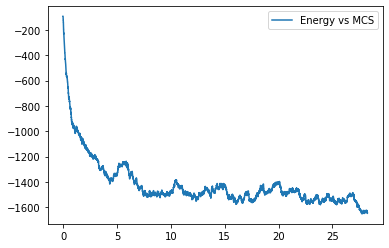

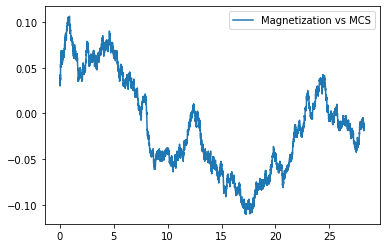

In [4]:
plt.plot(data_E["Time"], data_E["Energy"], label="Energy vs MCS")

plt.legend()  
plt.show()
plt.plot(
    data_M["Time"],
    data_M["Magnetization"],
    label="Magnetization vs MCS",
)
plt.legend()
plt.show()


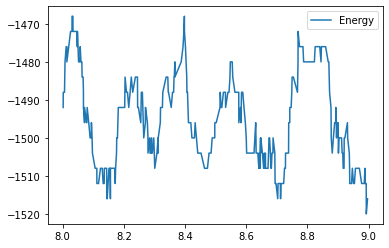

In [8]:
t1 = 8
t2 = 9

mask = (data_E["Time"] >= t1) & (data_E["Time"] <= t2)

plt.plot(
    data_E.loc[mask, "Time"],
    data_E.loc[mask, "Energy"],
    label="Energy"
)
plt.legend()
plt.show()